# TODO:
 - add an option to see general trends? so how likely is the hottest day in a given month over time
 - how many days over said temp per year
 - maybe temp of 5% percentile over time?
    - why 5%? also them to choose? isnt that p hacking?
 - choose temp and see percentile over time

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib import cm
from matplotlib.colors import ListedColormap


from temperature_history import get_temperature_history

In [2]:
def get_place_temp_data(place_name, date, start_year=1980, days_range=7):
    PLACES = {'yodfat': (32.8366, 35.2715), 
              'tlv': (32.0853, 34.7818),
              'vlc': (39.4738, -0.3756),
              'nowhere': (41.79, -0.16),
              'vitoria': (42.849998, -2.683333),
              'paris': (48.8575, 2.3514),
              'berlin': (52.5200, 13.4050)}
    place = PLACES[place_name]
    data = get_temperature_history(place[0], place[1], date, start_year, days_range)
    return data

date = "2025-08-13"
city = 'tlv'
days_range = 7
data = get_place_temp_data(city, date, 1950, days_range)

Fetching temperature data for 2025-08-13 ±7 days at 32.0853, 34.7818...
Making historical API call for date range: 1950-08-06 to 2025-08-12
Making forecast API call for forecast data untill 2025-08-13 00:00:00


In [3]:
data['date'] = pd.to_datetime(data['date'])
data['doy'] = data['date'].dt.dayofyear
data['date_diff'] = data['doy'] - pd.to_datetime(date).dayofyear

In [4]:
from datetime import datetime
dt = datetime.strptime(date, "%Y-%m-%d")
month_name = dt.strftime("%B")
day_num = dt.day

In [5]:
colors = [
    (48/255, 25/255, 52/255),   # dark purple
    (1.0, 0.0, 0.0),            # red
    #(1.0, 0.5, 0.0),            # orange
    (1.0, 0.7, 0.0),            # yellow
    (1.0, 1.0, 1.0),            # white (middle)
    (0, 0.7, 1),            # light blue
    (0.0, 0.0, 0.5),            # dark blue
    (0.6, 0.6, 0.6)             # grey
]

# Create the colormap
from matplotlib.colors import LinearSegmentedColormap

gpt_fire_cmap = LinearSegmentedColormap.from_list("fire_cmap", colors[::-1], N=256)

/tmp/ipykernel_2237/3447938600.py:1: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  rdbur = cm.get_cmap('RdBu_r', 256)


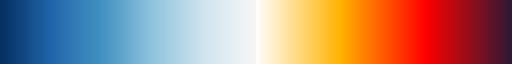

In [6]:
rdbur = cm.get_cmap('RdBu_r', 256)

rdbur_colors = rdbur(np.linspace(0, 1, 256))
gpt_fire_colors = gpt_fire_cmap(np.linspace(0, 1, 256))


# Darken the red side (start of the colormap)
# For example, multiply the RGB channels of the first half by 0.7
half = 128
gpt_fire_colors[:half, :3] = rdbur_colors[:half, :3] 

# Clip values to [0,1] to avoid overflows
colors = np.clip(gpt_fire_colors, 0, 1)

# Create new colormap
new_cmap = ListedColormap(colors)
new_cmap


In [7]:
import matplotlib.colors as mcolors
def add_color_legend(ax, cmap, vmin, vmax, label="Year"):

    # setup the normalization and the colormap
    normalize = mcolors.Normalize(vmin=vmin, vmax=vmax)

    # setup the colorbar
    scalarmappaple = cm.ScalarMappable(norm=normalize, cmap=cmap)
    cbar = plt.colorbar(scalarmappaple, ax=ax, label=label)
    
    # Reverse the order of the ticks
    if cbar.ax.yaxis.get_ticklabels():
        ticks = cbar.get_ticks()
        # Set the last tick to be vmax
        if len(ticks) > 0:
            ticks = list(ticks[::-1])
            del ticks[0]
        cbar.set_ticks(ticks)
        cbar.ax.invert_yaxis()

At 34.5°C 2025-08-13 is at the 1.1 percentile of daily max_temperature at tlv


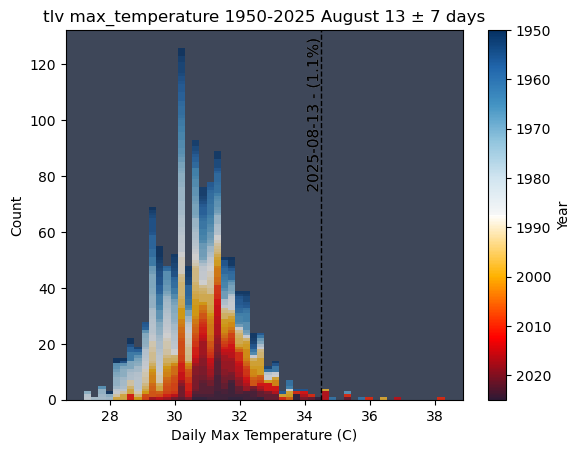

In [8]:
metric = 'max_temperature'
part_data = data[data['year'] > 1920]
ax = sns.histplot(data=part_data, stat="count", multiple="stack",
             x=metric, kde=False, edgecolor=None,
             palette=new_cmap, hue="year", bins=50,
             element="bars", legend=False)
# Get the last date's max_temperature
current_temp = part_data.loc[part_data['date'] == date, metric].values[0]

# Draw a red vertical line at the last temperature value
plt.axvline(current_temp, color='black', linestyle='--', linewidth=1)
import matplotlib.patheffects as patheffects

# Calculate the percentile: what percent of temperatures are higher than the last value
percent_higher = round((part_data[metric] > current_temp).mean() * 100, 1)

plt.text(
    current_temp,
    ax.get_ylim()[1]*0.98,
    f'{date} - ({percent_higher}%)',
    ha='right',
    va='top',
    fontsize=11,
    color='black',
    rotation=90,
    path_effects=[patheffects.withStroke(linewidth=0.1, foreground='white')]
)

print(f"At {current_temp}°C {date} is at the {percent_higher} percentile of daily {metric} at {city}")

plt.title(f'{city} {metric} {part_data.year.min()}-2025 {month_name} {day_num} ± {days_range} days')
ax.set_facecolor(0.7*np.array([0.35,0.4,0.5]))
#ax.set_facecolor('k')
if metric.startswith('min'):
    plt.xlabel('Daily Min Temperature (C)')
else:
    plt.xlabel('Daily Max Temperature (C)')
add_color_legend(ax, new_cmap, part_data.year.min(), part_data.year.max(), label="Year")



In [9]:
yearly_avgs = data.groupby('year')[['max_temperature', 'min_temperature']].agg([
    lambda x: x.quantile(0.10),
    lambda x: x.quantile(0.25),
    lambda x: x.quantile(0.5), 
    lambda x: x.quantile(0.75),
    lambda x: x.quantile(0.90)
]).reset_index()
yearly_avgs.columns = [
    'year',
    'max_temp_10th', 'max_temp_25th', 'max_temp_50th', 'max_temp_75th', 'max_temp_90th',
    'min_temp_10th', 'min_temp_25th', 'min_temp_50th', 'min_temp_75th', 'min_temp_90th'
]
yearly_avgs['date'] = pd.to_datetime(yearly_avgs['year'].astype(str) + '-' + month_name + '-' + str(day_num))
yearly_avgs

,year,max_temp_10th,max_temp_25th,max_temp_50th,max_temp_75th,max_temp_90th,min_temp_10th,min_temp_25th,min_temp_50th,min_temp_75th,min_temp_90th,date
0,1950,28.14,28.550,29.5,29.850,30.30,20.64,20.750,21.3,22.000,22.50,1950-08-13
1,1951,30.20,30.850,31.6,32.100,32.46,21.30,21.400,22.1,22.700,23.06,1951-08-13
2,1952,29.66,30.100,30.5,30.850,31.68,21.94,22.200,22.8,23.250,23.58,1952-08-13
3,1953,29.38,29.750,30.2,30.600,32.24,22.12,22.500,23.1,23.850,24.22,1953-08-13
4,1954,29.76,30.400,30.7,31.350,32.00,22.04,22.700,23.1,23.800,24.28,1954-08-13
...,...,...,...,...,...,...,...,...,...,...,...,...
71,2021,31.44,31.700,32.6,33.000,33.76,23.10,24.000,24.7,25.250,25.68,2021-08-13
72,2022,30.74,30.850,31.0,31.300,31.40,22.50,22.900,23.6,24.700,24.96,2022-08-13
73,2023,30.92,31.250,31.3,31.650,32.28,23.82,24.450,26.0,26.500,27.20,2023-08-13
74,2024,31.24,31.450,31.7,31.850,32.10,22.60,23.100,24.1,24.950,25.34,2024-08-13


/tmp/ipykernel_2237/969763306.py:34: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(loc=(1.02,0.65))


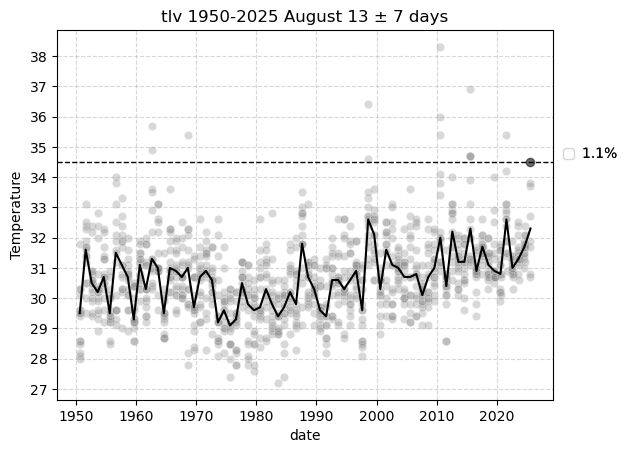

In [10]:
current_max_temp = data.loc[data['date'] == date, 'max_temperature'].values[0]
current_min_temp = data.loc[data['date'] == date, 'min_temperature'].values[0]
percent_higher_max = round((part_data['max_temperature'] > current_max_temp).mean() * 100, 1)
percent_higher_min = round((part_data['min_temperature'] > current_min_temp).mean() * 100, 1)

ax = sns.scatterplot(data=data, x='date', y='max_temperature', alpha=0.3, color='grey',)
#sns.scatterplot(data=data, x='date', y='min_temperature',  label='daily min temp', color='C0', alpha=0.5)


plt.axhline(current_max_temp, color='black', linestyle='--', linewidth=1)
#plt.axhline(current_min_temp, color='black', linestyle='--', linewidth=1)
plt.text(
    ax.get_xlim()[1]*1.18,
    current_max_temp + 0.5,
    f'{percent_higher_max}%',
    ha='right',
    va='top',
    fontsize=10,
    color='black',
    rotation=0,
    path_effects=[patheffects.withStroke(linewidth=0.1, foreground='white')]
)

import matplotlib.ticker as ticker
ax.yaxis.set_major_locator(ticker.MultipleLocator(1))  


plt.scatter(x=data.loc[data['date'] == date, 'date'].values[0], y=data.loc[data['date']==date, 'max_temperature'].values[0], color='black', alpha=0.5)
#plt.scatter(x=data.loc[data['date'] == date, 'date'].values[0], y=data.loc[data['date']==date, 'min_temperature'].values[0], color='black', alpha=0.5, label=date)
sns.lineplot(data=yearly_avgs, x='date', y='max_temp_50th', color='k', linestyle='-')
#sns.lineplot(data=yearly_avgs, x='date', y='max_temp_25th', color='k', linestyle='--')
#sns.lineplot(data=yearly_avgs, x='date', y='max_temp_75th', color='k', linestyle='--')

plt.legend(loc=(1.02,0.65))
plt.title(f'{city} {data.year.min()}-2025 {month_name} {day_num} ± {days_range} days')
plt.ylabel('Temperature')
plt.grid(True, linestyle='--', alpha=0.5, )


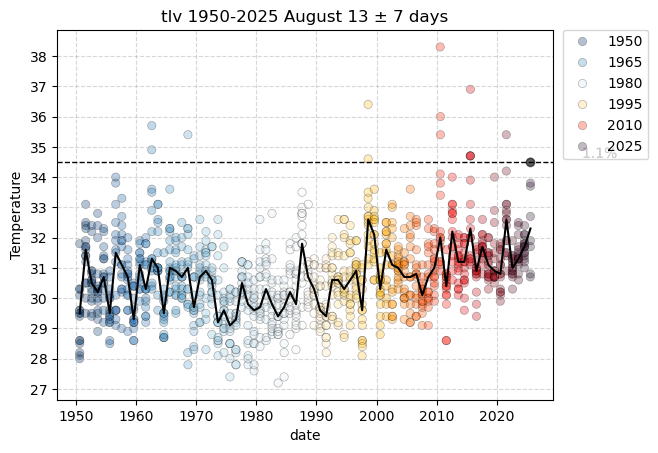

In [11]:
current_max_temp = data.loc[data['date'] == date, 'max_temperature'].values[0]
current_min_temp = data.loc[data['date'] == date, 'min_temperature'].values[0]
percent_higher_max = round((part_data['max_temperature'] > current_max_temp).mean() * 100, 1)
percent_higher_min = round((part_data['min_temperature'] > current_min_temp).mean() * 100, 1)

ax = sns.scatterplot(data=data, x='date', y='max_temperature',  hue='year', alpha=0.3, palette=new_cmap, edgecolor='k',)
#sns.scatterplot(data=data, x='date', y='min_temperature',  label='daily min temp', color='C0', alpha=0.5)


plt.axhline(current_max_temp, color='black', linestyle='--', linewidth=1)
#plt.axhline(current_min_temp, color='black', linestyle='--', linewidth=1)
plt.text(
    ax.get_xlim()[1]*1.18,
    current_max_temp + 0.5,
    f'{percent_higher_max}%',
    ha='right',
    va='top',
    fontsize=10,
    color='black',
    rotation=0,
    path_effects=[patheffects.withStroke(linewidth=0.1, foreground='white')]
)

import matplotlib.ticker as ticker
ax.yaxis.set_major_locator(ticker.MultipleLocator(1))  


plt.scatter(x=data.loc[data['date'] == date, 'date'].values[0], y=data.loc[data['date']==date, 'max_temperature'].values[0], color='black', alpha=0.5)
#plt.scatter(x=data.loc[data['date'] == date, 'date'].values[0], y=data.loc[data['date']==date, 'min_temperature'].values[0], color='black', alpha=0.5, label=date)
sns.lineplot(data=yearly_avgs, x='date', y='max_temp_50th', color='k', linestyle='-')
#sns.lineplot(data=yearly_avgs, x='date', y='max_temp_25th', color='k', linestyle='--')
#sns.lineplot(data=yearly_avgs, x='date', y='max_temp_75th', color='k', linestyle='--')

plt.legend(loc=(1.02,0.65))
plt.title(f'{city} {data.year.min()}-2025 {month_name} {day_num} ± {days_range} days')
plt.ylabel('Temperature')
plt.grid(True, linestyle='--', alpha=0.5, )


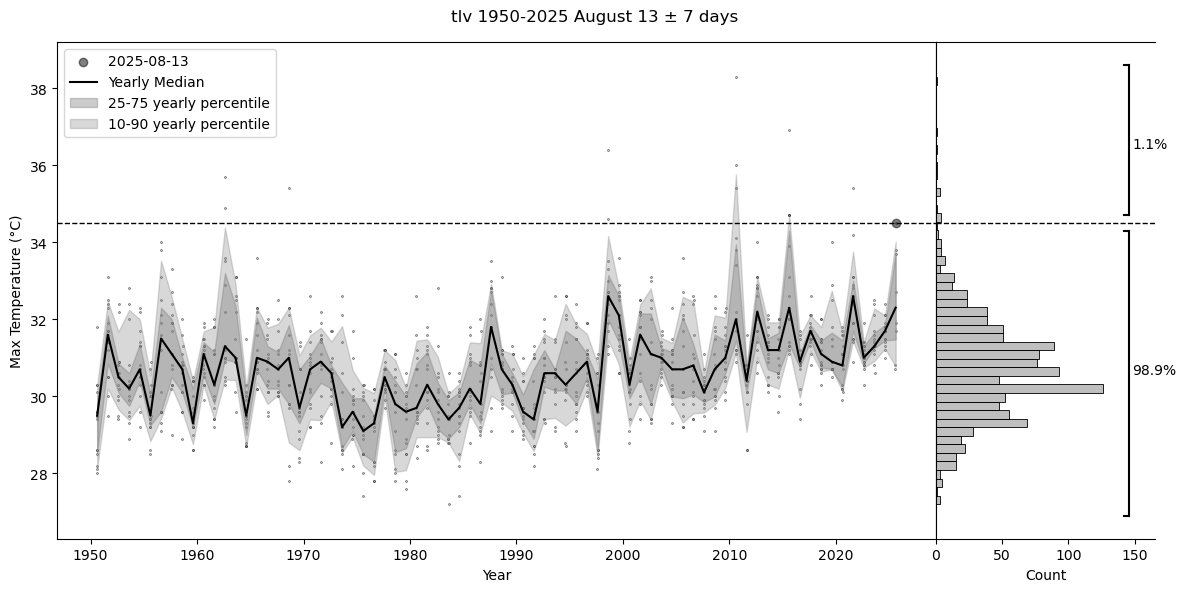

In [12]:
# Create figure with custom gridspec layout
fig = plt.figure(figsize=(12,6))
gs = fig.add_gridspec(1, 2, width_ratios=[4, 1], wspace=0)

# Main scatter plot
ax_main = fig.add_subplot(gs[0])
color='grey'
sns.scatterplot(data=data, x='date', y='max_temperature', alpha=0.5, color=color, s=2, 
                edgecolor='k', linewidth=0.5, ax=ax_main)
ax_main.axhline(current_max_temp, color='black', linestyle='--', linewidth=1)
ax_main.scatter(x=data.loc[data['date'] == date, 'date'].values[0], 
                y=data.loc[data['date']==date, 'max_temperature'].values[0], 
                color='black', alpha=0.5, label=date)
sns.lineplot(data=yearly_avgs, x='date', y='max_temp_50th', color='k', 
             linestyle='-', label='Yearly Median', ax=ax_main)
ax_main.fill_between(yearly_avgs['date'], 
                     yearly_avgs['max_temp_25th'], 
                     yearly_avgs['max_temp_75th'], 
                     color=color, 
                     alpha=0.4, label='25-75 yearly percentile')
ax_main.fill_between(yearly_avgs['date'], 
                     yearly_avgs['max_temp_10th'], 
                     yearly_avgs['max_temp_90th'], 
                     color=color, 
                     alpha=0.3, label='10-90 yearly percentile')

ax_main.set_xlabel('Year')
ax_main.set_ylabel('Max Temperature (°C)')

# Histogram on the right
ax_hist = fig.add_subplot(gs[1], sharey=ax_main)
sns.histplot(data=data, y='max_temperature', bins=50, color=color, alpha=0.5, ax=ax_hist)
ax_hist.axhline(current_max_temp, color='black', linestyle='--', linewidth=1)

# Remove y-axis labels from histogram
ax_hist.set_ylabel('')
ax_hist.tick_params(axis='y', which='both', left=False, labelleft=False)
# Add title to the figure
fig.suptitle(f'{city} {data.year.min()}-2025 {month_name} {day_num} ± {days_range} days')

# Add legend to main plot
ax_main.legend()

# Brackets and labels at the right
ymin, ymax = ax_hist.get_ylim()
xmin, xmax = ax_hist.get_xlim()
right_x = xmax + (xmax - xmin) * 0.1  # Position right of the plot
lower_bracket_width = current_max_temp - ymin - (ymax - ymin) * 0.02  # Extend almost to bottom
upper_bracket_width = ymax - current_max_temp - (ymax - ymin) * 0.02  # Extend almost to the top

bracket_depth = (xmax - xmin) * 0.03  # How far the bracket extends horizontally

bracket_distance = 0.2
# Upper bracket for higher percentile (above the line)
ax_hist.plot([right_x, right_x], [current_max_temp + bracket_distance, current_max_temp + upper_bracket_width], 'k-', linewidth=1.5)
ax_hist.plot([right_x, right_x - bracket_depth], [current_max_temp + bracket_distance, current_max_temp + bracket_distance], 'k-', linewidth=1.5)
ax_hist.plot([right_x, right_x - bracket_depth], [current_max_temp + upper_bracket_width, current_max_temp + upper_bracket_width], 
             'k-', linewidth=1.5)
ax_hist.text(right_x + (xmax - xmin) * 0.02, current_max_temp + upper_bracket_width/2, f'{percent_higher_max}%', 
             ha='left', va='center', fontsize=10)

# Lower bracket for lower percentile (below the line)
ax_hist.plot([right_x, right_x], [current_max_temp - lower_bracket_width, current_max_temp- bracket_distance], 'k-', linewidth=1.5)
ax_hist.plot([right_x, right_x - bracket_depth], [current_max_temp - lower_bracket_width, current_max_temp - lower_bracket_width], 
             'k-', linewidth=1.5)
ax_hist.plot([right_x, right_x - bracket_depth], [current_max_temp-bracket_distance, current_max_temp-bracket_distance], 'k-', linewidth=1.5)
ax_hist.text(right_x + (xmax - xmin) * 0.02, current_max_temp - lower_bracket_width/2, f'{round(100-percent_higher_max,1)}%', 
             ha='left', va='center', fontsize=10)

# Extend x-axis limits to show brackets
ax_hist.set_xlim(xmin, right_x + (xmax - xmin) * 0.15)
ax_hist.spines['right'].set_visible(False)

# Adjust layout
plt.tight_layout()

In [22]:
def plot_temperature_distribution(data, date, metric='max_temperature', color='grey', 
                                title=None, ax_main=None, ax_hist=None):
    """
    Creates a combination plot with temperature distribution over time and histogram.
    
    Parameters:
    -----------
    data : pandas.DataFrame
        Must contain columns: 'date', metric, 'year'
    date : str
        Date to highlight, format 'YYYY-MM-DD'
    metric : str
        Column name for temperature data (default: 'max_temperature')
    color : str
        Color for the plots (default: 'grey')
    title : str, optional
        Plot title. If None, will be generated automatically
    ax_main : matplotlib.axes.Axes, optional
        Axes for main plot. If None, new figure will be created
    ax_hist : matplotlib.axes.Axes, optional
        Axes for histogram. If None, new figure will be created
    
    Returns:
    --------
    fig : matplotlib.figure.Figure
    (ax_main, ax_hist) : tuple of matplotlib.axes.Axes
    """
    
    # Calculate yearly averages and percentiles
    yearly_avgs = data.groupby('year')[metric].agg([
        ('10th', lambda x: x.quantile(0.10)),
        ('25th', lambda x: x.quantile(0.25)),
        ('50th', lambda x: x.quantile(0.5)),
        ('75th', lambda x: x.quantile(0.75)),
        ('90th', lambda x: x.quantile(0.90))
    ]).reset_index()
    yearly_avgs['date'] = pd.to_datetime(yearly_avgs['year'].astype(str) + '-' + month_name + '-' + str(day_num))
    WINDOW_SIZE = 5
    yearly_avgs['moving_median'] = yearly_avgs['50th'].rolling(window=WINDOW_SIZE).median()
    yearly_avgs['moving_10th'] = yearly_avgs['10th'].rolling(window=WINDOW_SIZE).median()
    yearly_avgs['moving_25th'] = yearly_avgs['25th'].rolling(window=WINDOW_SIZE).median()
    yearly_avgs['moving_75th'] = yearly_avgs['75th'].rolling(window=WINDOW_SIZE).median()
    yearly_avgs['moving_90th'] = yearly_avgs['90th'].rolling(window=WINDOW_SIZE).median()

    
    # Get current temperature and calculate percentiles
    current_temp = data.loc[data['date'] == date, metric].values[0]
    percent_higher = round((data[metric] > current_temp).mean() * 100, 1)
    
    # Create new figure if axes not provided
    if ax_main is None or ax_hist is None:
        fig = plt.figure(figsize=(12,6))
        gs = fig.add_gridspec(1, 2, width_ratios=[4, 1], wspace=0)
        ax_main = fig.add_subplot(gs[0])
        ax_hist = fig.add_subplot(gs[1], sharey=ax_main)
    
    # Main scatter plot
    sns.scatterplot(data=data, x='date', y=metric, alpha=0.3, color=color, 
                    s=2, edgecolor='k', linewidth=0.5, ax=ax_main)
    ax_main.axhline(current_temp, color=color, linestyle='--', linewidth=1)
    ax_main.scatter(x=data.loc[data['date'] == date, 'date'].values[0],
                    y=current_temp, color=color, alpha=1, label=date)
    
    # Add trend lines and percentile bands
    sns.lineplot(data=yearly_avgs, x='date', y='moving_median', color=color,
                 linestyle='-', label=f'{WINDOW_SIZE} Year Median', ax=ax_main, )
    prefix = '' #'moving_'
    ax_main.fill_between(yearly_avgs['date'], yearly_avgs[f'{prefix}25th'],
                         yearly_avgs[f'{prefix}75th'], color=color,
                         alpha=0.2, label='25-75 yearly percentile')
    ax_main.fill_between(yearly_avgs['date'], yearly_avgs[f'{prefix}10th'],
                         yearly_avgs[f'{prefix}90th'], color=color,
                         alpha=0.2, label='10-90 yearly percentile')
    
    # Histogram
    sns.histplot(data=data, y=metric, bins=50, color=color, alpha=0.5, ax=ax_hist)
    ax_hist.axhline(current_temp, color=color, linestyle='--', linewidth=1)
    
    # Style and labels
    ax_main.set_xlabel('Year')
    ax_main.set_ylabel(f'Temperature (°C)')
    ax_hist.set_ylabel('')
    ax_hist.tick_params(axis='y', which='both', left=False, labelleft=False)
    
    # Add brackets and percentages
    ymin, ymax = ax_hist.get_ylim()
    xmin, xmax = ax_hist.get_xlim()
    add_percentage_brackets(ax_hist, current_temp, percent_higher, xmin, xmax, ymin, ymax)
    
    # Title
    if title is None:
        title = f'Temperature Distribution ({data.year.min()}-{data.year.max()})'
    ax_main.set_title(title)
    
    # Legend
    ax_main.legend()
    ax_main.grid(True, alpha=0.5, linestyle='-')
    return ax_main.figure, (ax_main, ax_hist)

def add_percentage_brackets(ax, current_temp, percent_higher, xmin, xmax, ymin, ymax):
    """Helper function to add percentage brackets to the histogram"""
    right_x = xmax + (xmax - xmin) * 0.1
    bracket_depth = (xmax - xmin) * 0.03
    bracket_distance = 0.2
    
    upper_bracket_width = ymax - current_temp - (ymax - ymin) * 0.02
    lower_bracket_width = current_temp - ymin - (ymax - ymin) * 0.02
    
    # Upper bracket
    ax.plot([right_x, right_x], 
            [current_temp + bracket_distance, current_temp + upper_bracket_width], 
            'k-', linewidth=1.5)
    ax.plot([right_x, right_x - bracket_depth], 
            [current_temp + bracket_distance, current_temp + bracket_distance], 
            'k-', linewidth=1.5)
    ax.plot([right_x, right_x - bracket_depth], 
            [current_temp + upper_bracket_width, current_temp + upper_bracket_width], 
            'k-', linewidth=1.5)
    
    # Lower bracket
    ax.plot([right_x, right_x], 
            [current_temp - lower_bracket_width, current_temp - bracket_distance], 
            'k-', linewidth=1.5)
    ax.plot([right_x, right_x - bracket_depth], 
            [current_temp - lower_bracket_width, current_temp - lower_bracket_width], 
            'k-', linewidth=1.5)
    ax.plot([right_x, right_x - bracket_depth], 
            [current_temp - bracket_distance, current_temp - bracket_distance], 
            'k-', linewidth=1.5)
    
    # Add percentage labels
    ax.text(right_x + (xmax - xmin) * 0.02, 
            current_temp + upper_bracket_width/2, 
            f'{percent_higher}%', 
            ha='left', va='center', fontsize=10)
    ax.text(right_x + (xmax - xmin) * 0.02, 
            current_temp - lower_bracket_width/2, 
            f'{round(100-percent_higher,1)}%', 
            ha='left', va='center', fontsize=10)
    
    ax.set_xlim(xmin, right_x + (xmax - xmin) * 0.15)
    ax.spines['right'].set_visible(False)


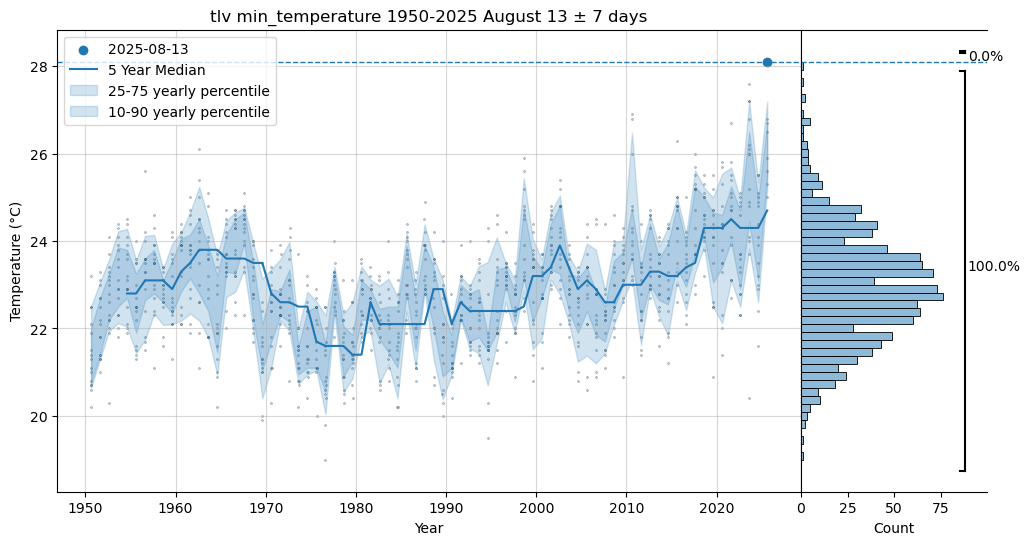

In [25]:
metric = 'min_temperature'
fig, (ax_main, ax_hist) = plot_temperature_distribution(
    data=data[data['year'] > 1920],
    date=date,
    metric=metric,
    color='C0',
    title=f'{city} {metric} {data.year.min()}-2025 {month_name} {day_num} ± {days_range} days'
)


In [27]:
yearly_avgs

,year,max_temp_10th,max_temp_25th,max_temp_50th,max_temp_75th,max_temp_90th,min_temp_10th,min_temp_25th,min_temp_50th,min_temp_75th,min_temp_90th,date
0,1950,28.14,28.550,29.5,29.850,30.30,20.64,20.750,21.3,22.000,22.50,1950-08-13
1,1951,30.20,30.850,31.6,32.100,32.46,21.30,21.400,22.1,22.700,23.06,1951-08-13
2,1952,29.66,30.100,30.5,30.850,31.68,21.94,22.200,22.8,23.250,23.58,1952-08-13
3,1953,29.38,29.750,30.2,30.600,32.24,22.12,22.500,23.1,23.850,24.22,1953-08-13
4,1954,29.76,30.400,30.7,31.350,32.00,22.04,22.700,23.1,23.800,24.28,1954-08-13
...,...,...,...,...,...,...,...,...,...,...,...,...
71,2021,31.44,31.700,32.6,33.000,33.76,23.10,24.000,24.7,25.250,25.68,2021-08-13
72,2022,30.74,30.850,31.0,31.300,31.40,22.50,22.900,23.6,24.700,24.96,2022-08-13
73,2023,30.92,31.250,31.3,31.650,32.28,23.82,24.450,26.0,26.500,27.20,2023-08-13
74,2024,31.24,31.450,31.7,31.850,32.10,22.60,23.100,24.1,24.950,25.34,2024-08-13


Text(0.5, 1.0, 'Number of days above 33°C')

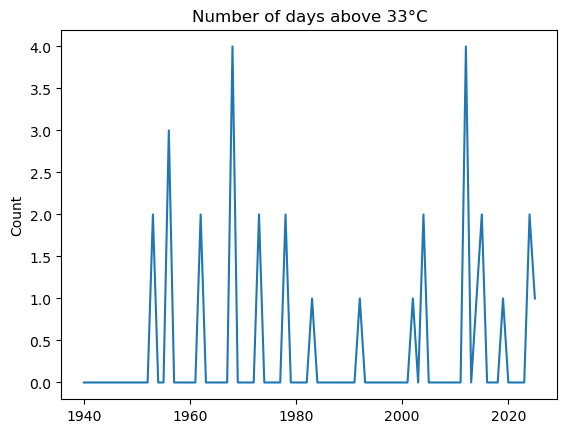

In [305]:
metric = 'max_temperature'
current_temp = 33 #data.loc[data['date'] == date, metric].values[0]
tmp_data = data.copy()
tmp_data['higher'] = tmp_data[metric] >= current_temp

plt.plot(tmp_data.groupby('year').higher.sum())
plt.ylabel('Count')
plt.title(f'Number of days above {current_temp}°C')


Text(0.5, 1.0, 'tlv max max_temperature 1940-2025 July 17 ± 7 days')

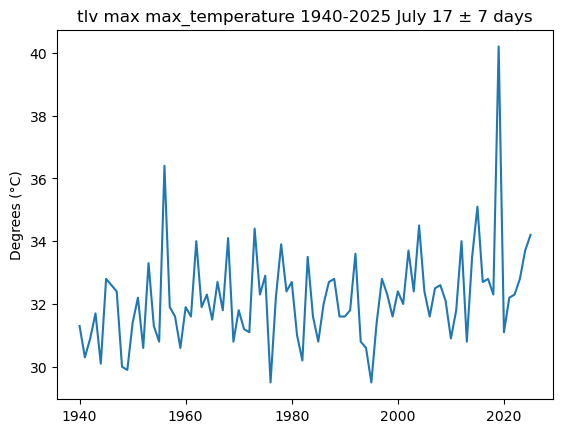

In [344]:
metric = 'max_temperature'

plt.plot(data.groupby('year')[metric].max())
plt.ylabel(f'Degrees (°C)')
plt.title(f'{city} max {metric} {data.year.min()}-2025 {month_name} {day_num} ± {days_range} days')

2025-07-17 is at the 0.6 percentile of max_temperature at 33.8 degrees


Text(0.5, 1.0, 'TLV max_temperature 1980-2025 July 17 +- 7 days (darker is older)')

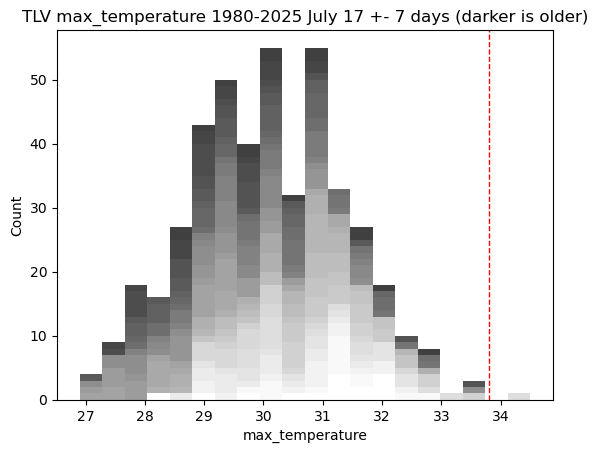

In [64]:
metric = 'max_temperature'
sns.histplot(data=data[data['year'] < 2010], stat="count", multiple="stack",
             x=metric, kde=False, edgecolor=None,
             palette="grey", hue="year", bins=20,
             element="bars", legend=False)
# Get the last date's max_temperature
current_temp = data.loc[data['date'] == date, metric].values[0]

# Draw a red vertical line at the last temperature value
plt.axvline(current_temp, color='red', linestyle='--', linewidth=1)

# Calculate the percentile: what percent of temperatures are higher than the last value
percent_higher = (data[metric] > current_temp).mean() * 100

print(f"{date} is at the {percent_higher:.1f} percentile of {metric} at {current_temp} degrees")

plt.title(f'TLV {metric} {data.year.min()}-2025 {month_name} {day_num} +- 7 days (darker is older)')


In [38]:
data.head()

,date,year,min_temperature,max_temperature,data_type
0,1980-07-10,1980,21.5,30.4,historical
1,1980-07-11,1980,21.8,31.5,historical
2,1980-07-12,1980,21.1,32.7,historical
3,1980-07-13,1980,21.7,31.9,historical
4,1980-07-14,1980,21.5,29.9,historical


<Axes: xlabel='year', ylabel='min_temperature'>

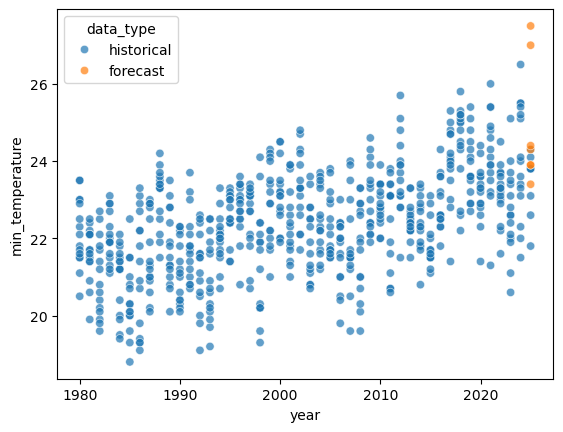

In [42]:
sns.scatterplot(data=data, x='year', y='min_temperature', hue='data_type', alpha=0.7)

2024-07-23 is at the 1.6 percentile of min_temperature at 25.2 degrees


Text(0.5, 1.0, 'TLV min_temperature daily temp 1980-2024 mid july (darker is older)')

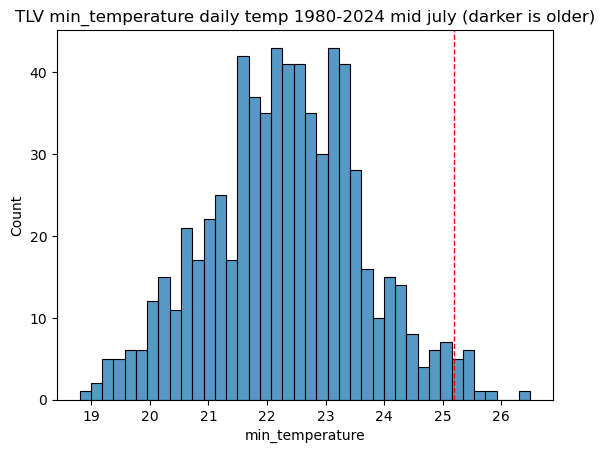

In [ ]:
metric = 'min_temperature'
sns.histplot(data=data, stat="count", multiple="stack",
             x=metric, kde=False, bins=40,
             element="bars", legend=False)
# Get the last date's max_temperature
last_row = data.sort_values("date").iloc[-1]
current_temp = last_row[metric]

# Draw a red vertical line at the last temperature value
plt.axvline(current_temp, color='red', linestyle='--', linewidth=1)

# Calculate the percentile: what percent of temperatures are higher than the last value
percent_higher = (data[metric] > current_temp).mean() * 100

print(f"{last_row['date']} is at the {percent_higher:.1f} percentile of {metric} at {current_temp} degrees")

plt.title(f'TLV {metric} daily temp 1980-2024 mid july (darker is older)')


<Axes: xlabel='year', ylabel='min_temperature'>

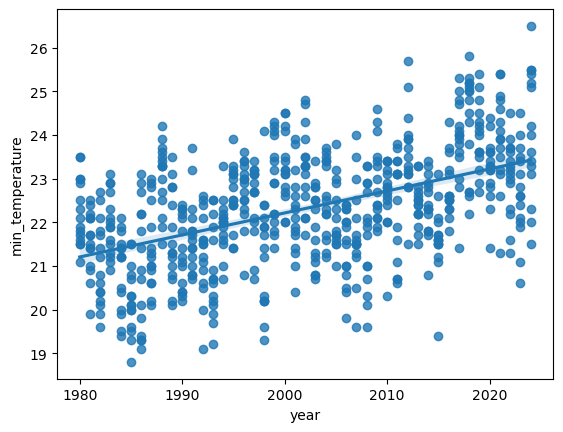

In [36]:
sns.regplot(data=test, y="min_temperature", x="year")